## Human Activity Recognition

Given *data about human movement and acitivity*, let's try to predict the **activity** that a given human is peforming.

We will use a TensorFlow ANN to make our predictions.

Data source: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones

### Importing Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

import tensorflow as tf

In [31]:
tf.random.set_seed(48)

In [32]:
train_df = pd.read_csv('archive/train.csv')
test_df = pd.read_csv('archive/test.csv')

In [33]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 31.6 MB


In [34]:
train_df

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,30,WALKING_UPSTAIRS
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,30,WALKING_UPSTAIRS
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,30,WALKING_UPSTAIRS
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339,30,WALKING_UPSTAIRS


In [35]:
train_df.mean(numeric_only=True)

tBodyAcc-mean()-X                        0.274488
tBodyAcc-mean()-Y                       -0.017695
tBodyAcc-mean()-Z                       -0.109141
tBodyAcc-std()-X                        -0.605438
tBodyAcc-std()-Y                        -0.510938
                                          ...    
angle(tBodyGyroJerkMean,gravityMean)    -0.005981
angle(X,gravityMean)                    -0.489547
angle(Y,gravityMean)                     0.058593
angle(Z,gravityMean)                    -0.056515
subject                                 17.413085
Length: 562, dtype: float64

In [36]:
print("Train set missing values:", train_df.isna().sum().sum())

Train set missing values: 0


In [37]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 12.7 MB


In [38]:
print("Test set missing values:", test_df.isna().sum().sum())

Test set missing values: 0


In [39]:
# Splitting Data into X and y
y_train = train_df['Activity'].copy()
X_train = train_df.drop('Activity', axis=1).copy()

y_test = test_df['Activity'].copy()
X_test = test_df.drop('Activity', axis=1).copy()

### Encoding Labels

In [40]:
y_train

0               STANDING
1               STANDING
2               STANDING
3               STANDING
4               STANDING
              ...       
7347    WALKING_UPSTAIRS
7348    WALKING_UPSTAIRS
7349    WALKING_UPSTAIRS
7350    WALKING_UPSTAIRS
7351    WALKING_UPSTAIRS
Name: Activity, Length: 7352, dtype: str

In [41]:
y_train.value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [42]:
num_classes = 6

In [43]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train = label_encoder.transform(y_train)
y_test = label_encoder.transform(y_test)

In [44]:
# Scale Data
# scaler = StandardScaler()
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Modeling/Training

In [45]:
inputs = tf.keras.Input(shape=(X_train.shape[1],))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [46]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 562)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │          36,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,582 (158.52 KB)

 Trainable params: 40,582 (158.52 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

batch_size = 32
epochs = 25

history = model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    batch_size = batch_size,
    epochs = epochs,
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint('./model.h5', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.1,
            patience=1
        )
    ]
)

Epoch 1/25
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7459 - loss: 0.6606

184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7465 - loss: 0.6591 - val_accuracy: 0.9164 - val_loss: 0.3203 - learning_rate: 0.0010
Epoch 2/25
182/184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8999 - loss: 0.2694

184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9002 - loss: 0.2686 - val_accuracy: 0.9375 - val_loss: 0.2051 - learning_rate: 0.0010
Epoch 3/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9339 - loss: 0.1741

184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9339 - loss: 0.1741 - val_accuracy: 0.9293 - val_loss: 0.1818 - learning_rate: 0.0010
Epoch 4/25
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9590 - loss: 0.1250

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9592 - loss: 0.1248 - val_accuracy: 0.9347 - val_loss: 0.1535 - learning_rate: 1.0000e-04
Epoch 5/25
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9601 - loss: 0.1219

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9604 - loss: 0.1214 - val_accuracy: 0.9409 - val_loss: 0.1529 - learning_rate: 1.0000e-05
Epoch 6/25
166/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9616 - loss: 0.1200

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9617 - loss: 0.1199 - val_accuracy: 0.9409 - val_loss: 0.1525 - learning_rate: 1.0000e-05
Epoch 7/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9617 - loss: 0.1195 - val_accuracy: 0.9415 - val_loss: 0.1528 - learning_rate: 1.0000e-06
Epoch 8/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9617 - loss: 0.1194 - val_accuracy: 0.9415 - val_loss: 0.1530 - learning_rate: 1.0000e-06
Epoch 9/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9616 - loss: 0.1193 - val_accuracy: 0.9415 - val_loss: 0.1531 - learning_rate: 1.0000e-07
Epoch 10/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9616 - loss: 0.1193 - val_accuracy: 0.9415 - val_loss: 0.1531 - learning_rate: 1.0000e-08
Epoch 11/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9616 - loss: 0.1193 - val_accuracy: 0.9415 - val_loss: 0.1531 - learning_rate: 1.0000e-09
Epoch 12/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9616 -

### Results

In [48]:
history.history

{'accuracy': [0.7464717030525208,
  0.9001870155334473,
  0.9338547587394714,
  0.9591906070709229,
  0.9603809118270874,
  0.9617412090301514,
  0.9617412090301514,
  0.9617412090301514,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072,
  0.9615711569786072],
 'loss': [0.65911865234375,
  0.26862406730651855,
  0.17407989501953125,
  0.12481594830751419,
  0.12139400839805603,
  0.1199287548661232,
  0.11952163279056549,
  0.1193884089589119,
  0.11928484588861465,
  0.11927470564842224,
  0.11927404254674911,
  0.11927404999732971,
  0.11927404999732971,
  0.11927404999732971,
  0.11927404999732971,
  0.11927404999732971,
  0.11927404999732971,
  0.11927404999732971,
  0.1192740499973297

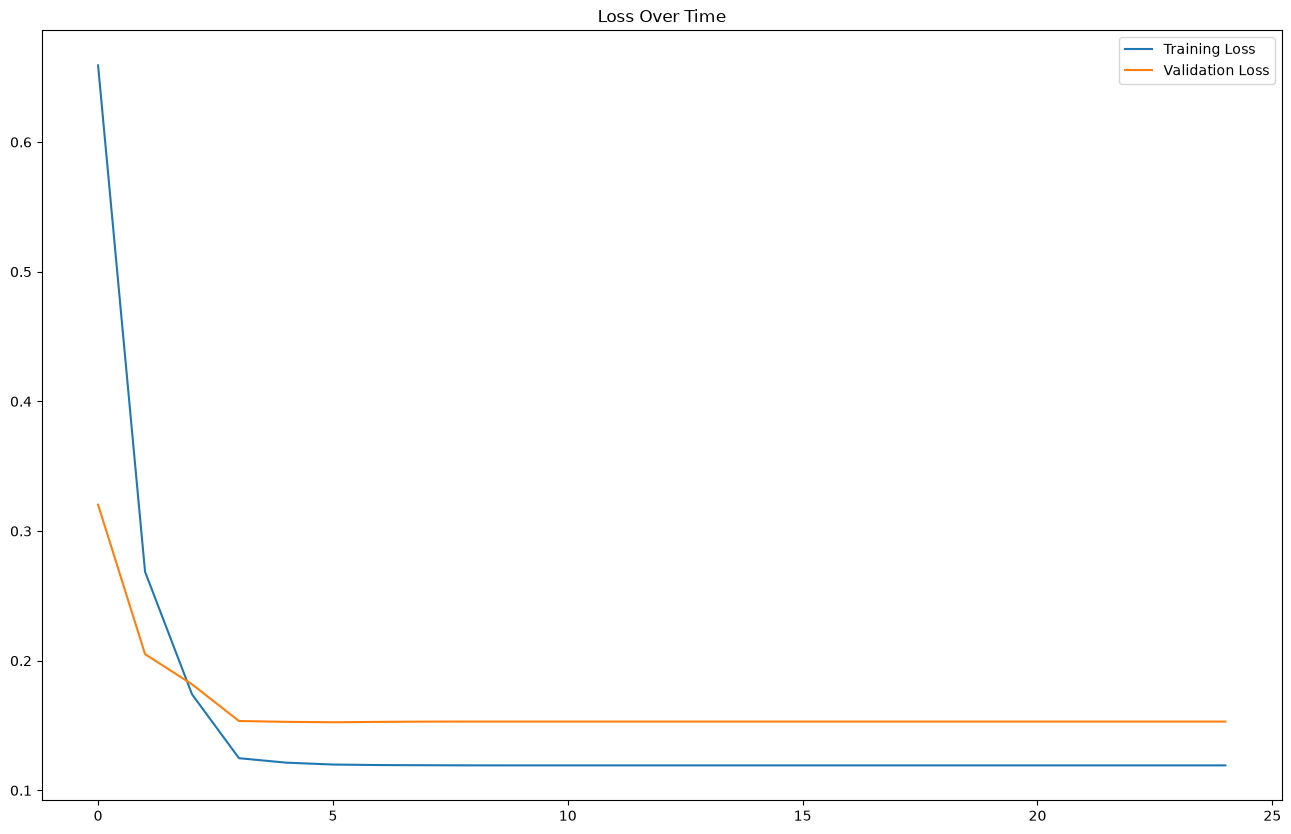

In [49]:
plt.figure(figsize=(16,10))

epochs_range = range(epochs)
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(
    epochs_range,
    train_loss,
    label='Training Loss'
)

plt.plot(
    epochs_range,
    val_loss,
    label='Validation Loss'
)

plt.legend()
plt.title('Loss Over Time')
plt.show()

In [50]:
model.evaluate(X_test, y_test)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9209 - loss: 0.2030


[0.20301641523838043, 0.9209365248680115]

In [51]:
model.load_weights('./model.h5')

In [52]:
# Standard Scaler accuracy: 0.9338